
AI Disclosure: Artificial Intelligence was not used to generate any code nor comment in this notebook. However, 
LLMs were used to research on techniques to apply and refresh on some of the coding concepts that we implement.

---

In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from prophet import Prophet

/Users/eric/Desktop/work/02_bse/t3_intelligent-dd/idd_final-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


### 1) Initial Data Exploration and Visualization

In [2]:
# Load the data and check types

data = pd.read_csv('../data/train_data.csv')

print(f"Data shape: {data.shape}\n")

print("=== Sample of 10 Random Rows ===")
display(data.sample(10))

print("=== Data Types ===")
display(data.dtypes)

print("=== NaN Value Analysis ===")
display(data.isna().value_counts())

Data shape: (8550, 3)

=== Sample of 10 Random Rows ===


,time,orders,city
4526,2021-08-09 02:00:00,0.0,BCN
5746,2021-09-28 22:00:00,174.0,BCN
2977,2021-06-05 07:00:00,2.0,BCN
383,2021-02-17 05:00:00,0.0,BCN
5729,2021-09-28 05:00:00,0.0,BCN
48,2021-02-03 00:00:00,0.0,BCN
3668,2021-07-04 08:00:00,14.0,BCN
2069,2021-04-28 11:00:00,23.0,BCN
2396,2021-05-12 02:00:00,0.0,BCN
7986,2021-12-31 12:00:00,111.0,BCN


=== Data Types ===


time          str
orders    float64
city          str
dtype: object

=== NaN Value Analysis ===


time   orders  city 
False  False   False    8550
Name: count, dtype: int64

New data typer for 'time': datetime64[us]

Data range: 2021-02-01 00:00:00 to 2022-01-23 23:00:00


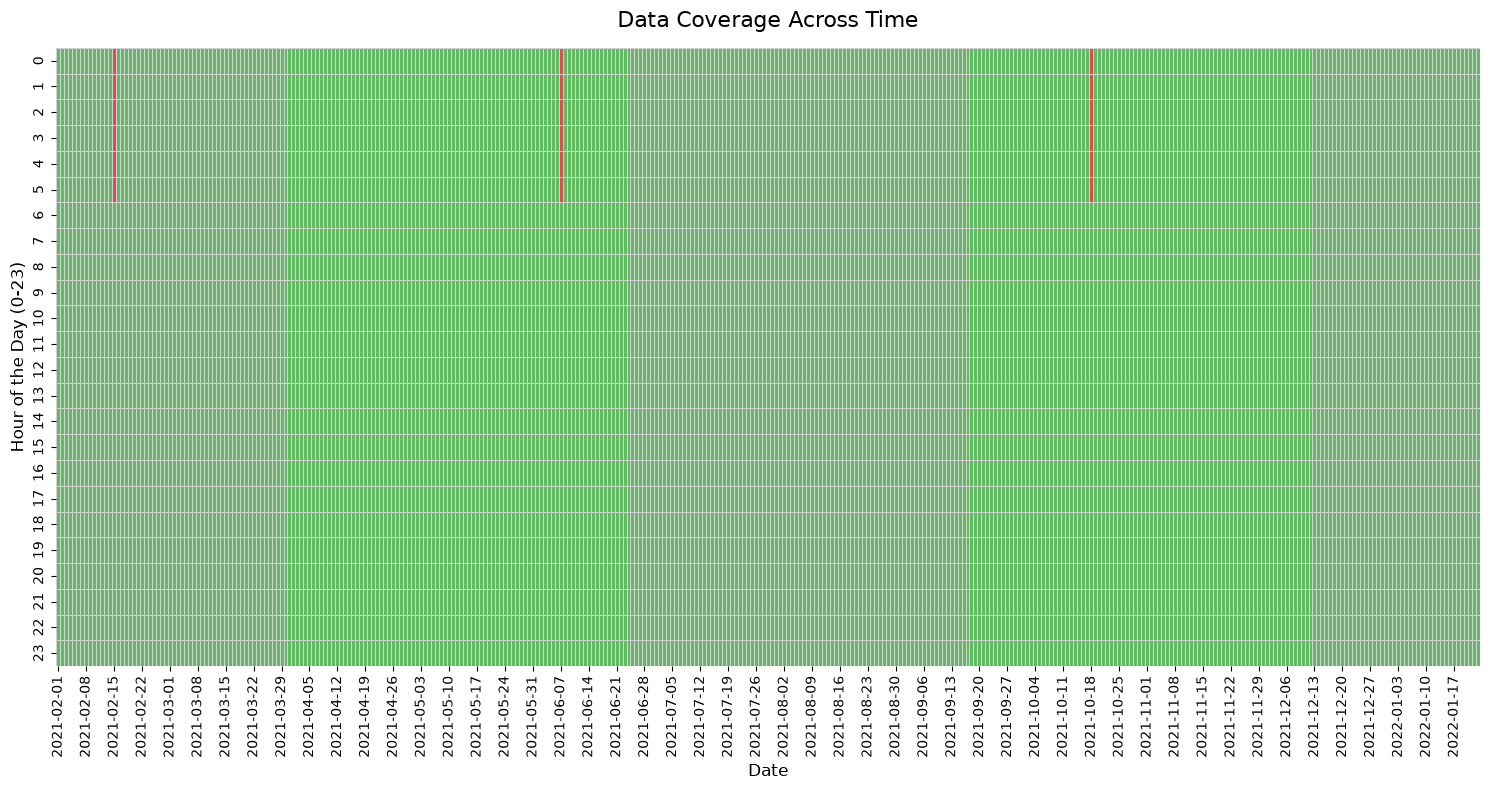

=== List of Missing Slots ===


,date,hour
336,2021-02-15,0
337,2021-02-15,1
338,2021-02-15,2
339,2021-02-15,3
340,2021-02-15,4
341,2021-02-15,5
3024,2021-06-07,0
3025,2021-06-07,1
3026,2021-06-07,2
3027,2021-06-07,3


In [3]:
# Messing with time

# We just saw that time is type str, we
# transform to datetime
data['time'] = pd.to_datetime(data['time'])
print(f"New data typer for 'time': {data['time'].dtype}\n")

# Time range
print(f"Data range: {min(data['time'])} to {max(data['time'])}")

# Time coverage plot
data['date'] = data['time'].dt.date
data['hour'] = data['time'].dt.hour

coverage = data.groupby(['date', 'hour']).size().reset_index(name='count')
coverage['data_present'] = 1

coverage_matrix = coverage.pivot(index='hour', columns='date', values='data_present')
coverage_matrix = coverage_matrix.reindex(index=range(24))

plt.figure(figsize=(15, 8))

ax = sns.heatmap(
    coverage_matrix, 
    cmap=["#61b961"],     
    cbar=False,           
    linewidths=0.5,       
    linecolor='lightgray',
    xticklabels=7
)

ax.set_facecolor("#de4d4d") 
plt.title('Data Coverage Across Time', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Hour of the Day (0-23)', fontsize=12)
plt.xticks(rotation=90) 

plt.tight_layout()
plt.show()


# List of missing slots
full_list = coverage_matrix.reset_index().melt(
    id_vars='hour', 
    var_name='date', 
    value_name='status'
)

missing_data = full_list[full_list['status'].isna()]
missing_list = missing_data[['date', 'hour']]

# Print the results
print("=== List of Missing Slots ===")
display(missing_list)

=== Descriptive Statistics for Orders ===


,orders
count,8550.000000
mean,72.878199
std,110.743494
min,0.000000
25%,0.000000
50%,30.000000
75%,96.000000
max,939.000000


=== Outlier Detection ===
Outliers found: 712 (8.33% of the data)

=== Order Histogram ===


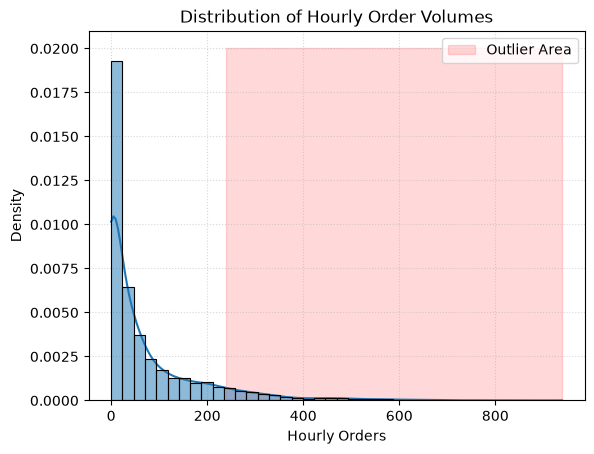

In [21]:
print("=== Descriptive Statistics for Orders ===")
display(data[['orders']].describe())

q1 = data['orders'].quantile(0.25)
q3 = data['orders'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("=== Outlier Detection ===")
outliers = data[(data['orders'] < lower_bound) | (data['orders'] > upper_bound)]
print(f"Outliers found: {len(outliers)} ({round(len(outliers)/len(data)*100, 2)}% of the data)\n")

print("=== Order Histogram ===")
sns.histplot(data['orders'], bins=40, kde=True, stat='density', zorder=100)
plt.fill_between(x=[upper_bound, max(data['orders'])], y1=[0.02, 0.02], color='red', alpha=0.15, label = 'Outlier Area')
plt.title('Distribution of Hourly Order Volumes')
plt.xlabel('Hourly Orders')
plt.grid(alpha=0.5, linestyle=':')
plt.legend(loc='upper right')
plt.show()


### 2) Trends, Cycles, and Seasonality

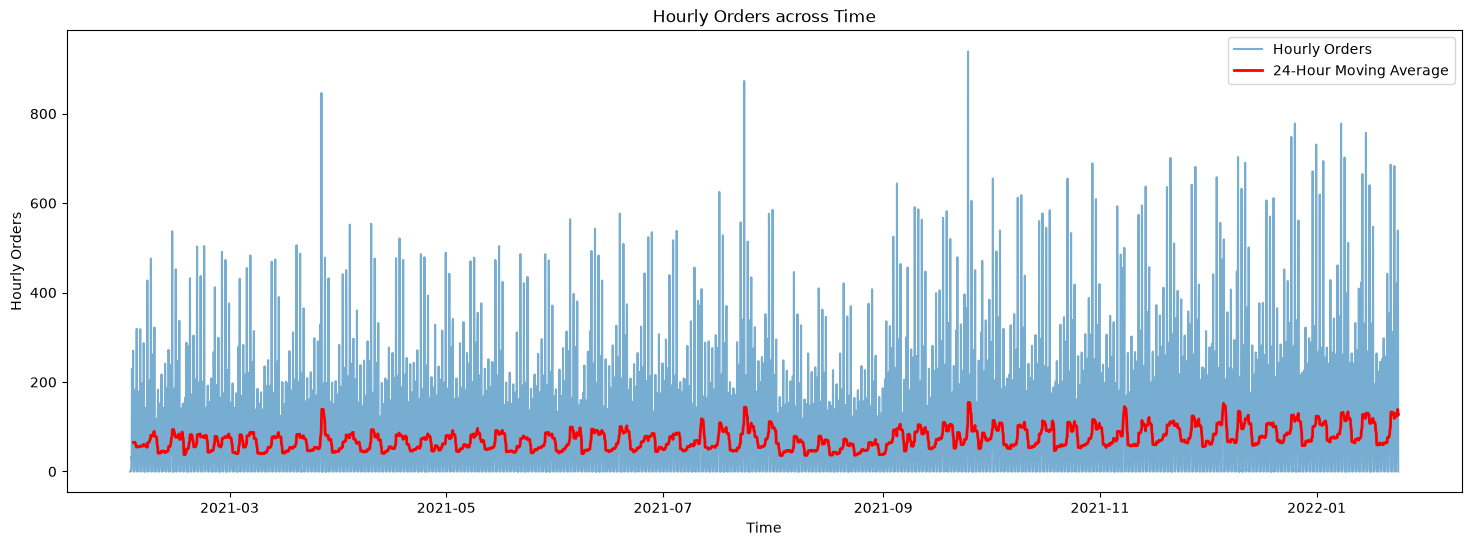

In [19]:
# Time-series plot
window_size = 24 
data['moving_avg'] = data['orders'].rolling(window=window_size).mean()

plt.figure(figsize=(18, 6))
plt.plot(data['time'], data['orders'], label='Hourly Orders', alpha=0.6, color='tab:blue')
plt.plot(data['time'], data['moving_avg'], label=f'{window_size}-Hour Moving Average', color='red', linewidth=2)

plt.title('Hourly Orders across Time')
plt.ylabel('Hourly Orders')
plt.xlabel('Time')

plt.legend()
plt.show()

15:13:06 - cmdstanpy - INFO - Chain [1] start processing
15:13:06 - cmdstanpy - INFO - Chain [1] done processing


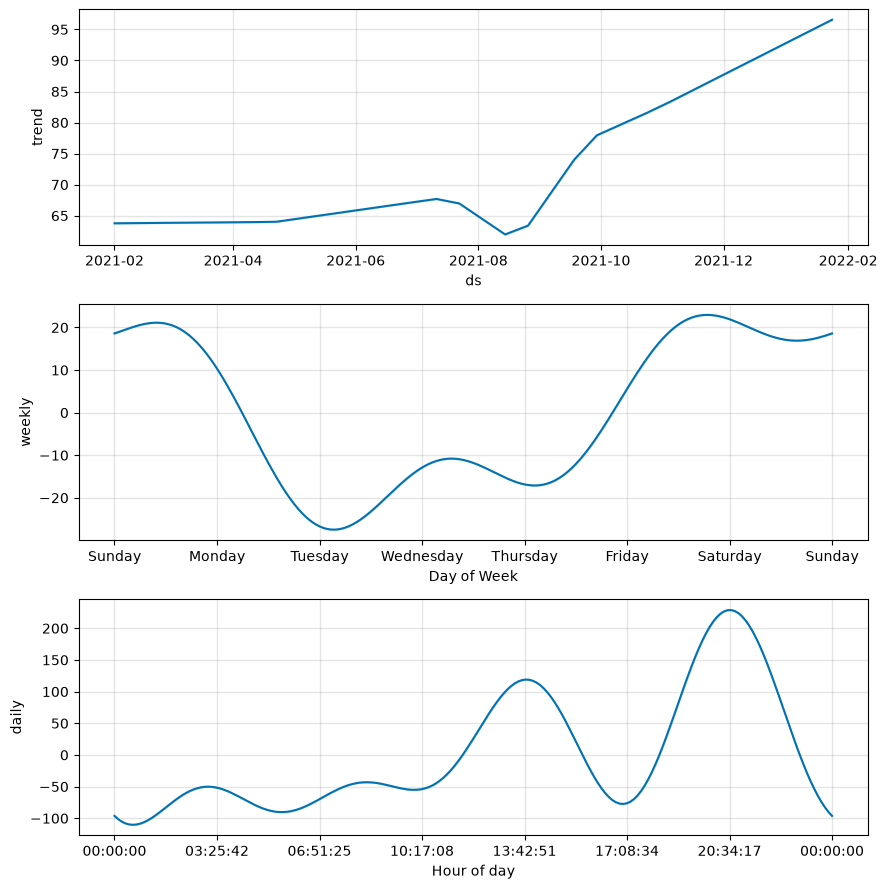

In [ ]:
# Seasonality decomposition
prophet_df = data.reset_index()
prophet_df = prophet_df[['time', 'orders']].rename(columns={'time': 'ds', 'orders': 'y'})


# We don't model a yearly seasonal cycle because
# to model a seasonal cycle, the algorithm needs 
# to see that cycle repeat at least twice 
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=True
)
m.fit(prophet_df)

forecast = m.predict(prophet_df)
fig = m.plot_components(forecast)

### How does our EDA inform the modeling?

- No NaNs: across the whole dataset, there are no NaN values in either of the columns (time, orders, city).
- Time range: the first data point is from 2021-02-01 at 0:00:00, and the last one is from 2022-01-23 at 23:00:00
- Missing dates: we have identified several slots missing from the dataset, specifically:
    - For 2021-02-15, from 0:00:00 t0 5:00:00
    - For 2021-06-07, from 0:00:00 t0 5:00:00
    - For 2021-10-18, from 0:00:00 t0 5:00:00
- The order distribution is right-skewed, and resembles a log-normal, with more than 25% of the hourly orders being 0. The median value
is 30, and the mean hourly orders are 73. The maximum number of orders in an hour are 939. Using the Interquartile Range for outlier detection,
we find that 8.33% of the obsrvations are outliers, which correspond to 712 slots.
- The series can be decomposed into a trend, weekly, and daily cycles.
    - Trend: throughout the period of analysis, hourly workers exhibit a clear upward trend, increasing from roughly 65 to just above 95 hourly orders.
    - Weekly: within a given week, two clear periods can be identified: a first one, that corresponds to the weekend days and Friday; and a second one, 
    which includes Monday through Thursday. The former is characterized by high levels in hourly orders (between 10 and 20), whereas the latter stays in
    the range [-30, -10].
    - Daily: within a day, a clear pattern emerges. From midnight and until Spanish lunch time (starting at 1pm), the number of hourly orders is stable,
    and at a low level; in the range [-100, -50]. Then, at lunch time, we can observe a peak, which descends into a valley as the afternoon progresses,
    reaching a local minima roughly at 5pm. From then onwards, an increasing tendency emerges, which peaks around 8:30pm, right around Spanish dinner time.
    After dinner time, the number of hourly orders stabilizes back again at a low range.
    - Notice that we do not include a yearly seasonality because the data does not include that seasonal cycle more than once, and in fact, it does not even
    include it once, as we do not have any data for the last few days of January. 